['./rgb_jpg_native\\oyla_0001.jpg', './rgb_jpg_native\\oyla_0003.jpg', './rgb_jpg_native\\oyla_0005.jpg', './rgb_jpg_native\\oyla_0007.jpg', './rgb_jpg_native\\oyla_0009.jpg', './rgb_jpg_native\\oyla_0011.jpg', './rgb_jpg_native\\oyla_0013.jpg', './rgb_jpg_native\\oyla_0015.jpg', './rgb_jpg_native\\oyla_0017.jpg', './rgb_jpg_native\\oyla_0019.jpg', './rgb_jpg_native\\oyla_0021.jpg', './rgb_jpg_native\\oyla_0023.jpg', './rgb_jpg_native\\oyla_0025.jpg', './rgb_jpg_native\\oyla_0027.jpg', './rgb_jpg_native\\oyla_0029.jpg', './rgb_jpg_native\\oyla_0031.jpg', './rgb_jpg_native\\oyla_0033.jpg', './rgb_jpg_native\\oyla_0035.jpg', './rgb_jpg_native\\oyla_0037.jpg']


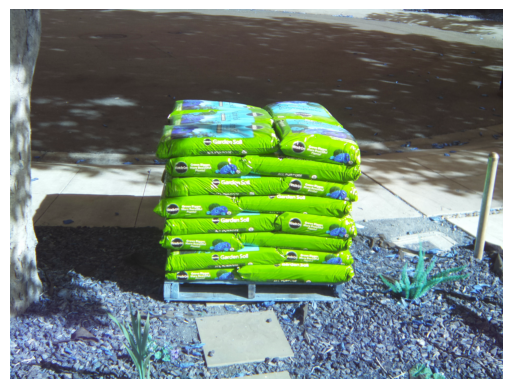

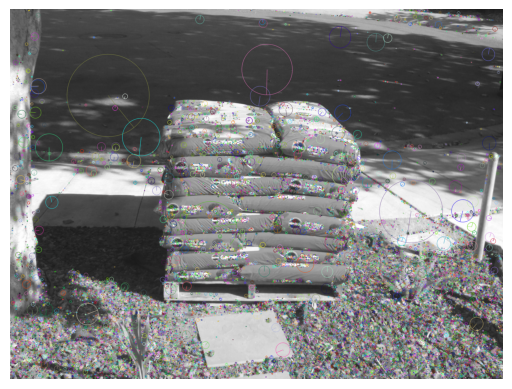

In [1]:
import os 
image_folder = "./rgb_jpg_native"
images = os.listdir(image_folder)
images = [os.path.join(image_folder,image) for image in images]
print(images)
import cv2
import matplotlib.pyplot as plt

# Loading the image
img = cv2.imread(images[0])
plt.imshow(img)
plt.axis('off')  
plt.show()
 # Converting image to grayscale
gray= cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# Applying SIFT detector
sift = cv2.SIFT_create()
kp = sift.detect(gray, None)

# Marking the keypoint on the image using circles
img=cv2.drawKeypoints(gray ,
                      kp ,
                      img ,
                      flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.imshow(img)
plt.axis('off')  
plt.show()

In [8]:
keypoints = []
descriptors = []
for image in images:
    img = cv2.imread(image)
    kp, desc = sift.detectAndCompute(img,None)
    keypoints.append(kp)
    descriptors.append(desc)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)   # or pass empty dictionary
 
flann = cv2.FlannBasedMatcher(index_params,search_params)

matches_array = []
total_average = 0
total = 0
for i in range(1,len(descriptors)):
    matches = flann.knnMatch(descriptors[i-1],descriptors[i],k=2)
    average_distance = 0
    for j,(m,n) in enumerate(matches):
        average_distance += m.distance
    total += average_distance
    average_distance = average_distance/len(matches)
    print(f"matches for images { os.path.basename(images[i-1])}, { os.path.basename(images[i])} has average distance: {average_distance}")
    total_average+=average_distance
print(f"Total distance = {total_average}")	
total_average = total_average/(len(descriptors)-1)
print(f"Total average distance = {total_average}")	
		

matches for images oyla_0001.jpg, oyla_0003.jpg has average distance: 237.81364866737533
matches for images oyla_0003.jpg, oyla_0005.jpg has average distance: 229.7545294716809
matches for images oyla_0005.jpg, oyla_0007.jpg has average distance: 243.92791253718596
matches for images oyla_0007.jpg, oyla_0009.jpg has average distance: 256.4054789543152
matches for images oyla_0009.jpg, oyla_0011.jpg has average distance: 233.7619683358128
matches for images oyla_0011.jpg, oyla_0013.jpg has average distance: 253.45238930885262
matches for images oyla_0013.jpg, oyla_0015.jpg has average distance: 156.26153128897485
matches for images oyla_0015.jpg, oyla_0017.jpg has average distance: 274.2996516716691
matches for images oyla_0017.jpg, oyla_0019.jpg has average distance: 270.68755440648386
matches for images oyla_0019.jpg, oyla_0021.jpg has average distance: 270.90121750037736
matches for images oyla_0021.jpg, oyla_0023.jpg has average distance: 278.7952101179714
matches for images oyla_00

In [6]:
import random
new_total_average = 0
new_total = 0
for i in range(19):
    random_images =  random.sample(images,2)
    img1 = cv2.imread(random_images[0])
    img2 = cv2.imread(random_images[1])
    kp1, desc1 = sift.detectAndCompute(img1,None)
    kp2, desc2 = sift.detectAndCompute(img2,None)
    matches = flann.knnMatch(desc1,desc2,k=2)
    average_distance = 0
    for j,(m,n) in enumerate(matches):
        average_distance += m.distance
    new_total+=average_distance
    average_distance = average_distance/len(matches)
    print(f"matches for images { os.path.basename(random_images[0])}, { os.path.basename(random_images[1])} has average distance: {average_distance}")
    new_total_average+=average_distance

print(f"Total distance = {new_total}")	
new_total_average = new_total_average/19
print(f"Total average distance = {new_total_average}")
    

matches for images oyla_0021.jpg, oyla_0005.jpg has average distance: 296.71751809753414
matches for images oyla_0015.jpg, oyla_0011.jpg has average distance: 252.6216777848162
matches for images oyla_0021.jpg, oyla_0013.jpg has average distance: 295.07158725572845
matches for images oyla_0017.jpg, oyla_0037.jpg has average distance: 299.53062686317173
matches for images oyla_0021.jpg, oyla_0031.jpg has average distance: 300.6635262348567
matches for images oyla_0029.jpg, oyla_0017.jpg has average distance: 287.019421402157
matches for images oyla_0015.jpg, oyla_0033.jpg has average distance: 295.9495149313264
matches for images oyla_0007.jpg, oyla_0029.jpg has average distance: 302.9515428723649
matches for images oyla_0015.jpg, oyla_0027.jpg has average distance: 298.0544535560159
matches for images oyla_0007.jpg, oyla_0037.jpg has average distance: 300.57689010210123
matches for images oyla_0021.jpg, oyla_0019.jpg has average distance: 274.1319226864017
matches for images oyla_0031.